# APRENDIZAJE AUTOMÁTICO
# Práctica 2: Regularización y Selección de Modelos
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 13-02-2026
---



## Configuración

In [8]:
%matplotlib inline
# try:
#   from google.colab import drive
#   print("Trabajando en Colab")
#   drive.mount('/content/drive')                # Monta tu google drive
#   Path = '/content/drive/MyDrive/Aprendizaje/' # Directorio donde guardas los ficheros
# except:
print("Trabajando en local")
import os
Path = os.getcwd() + "/"                                  # Directorio donde guardas los ficheros

Trabajando en local


---
## 0. Visualización de datos

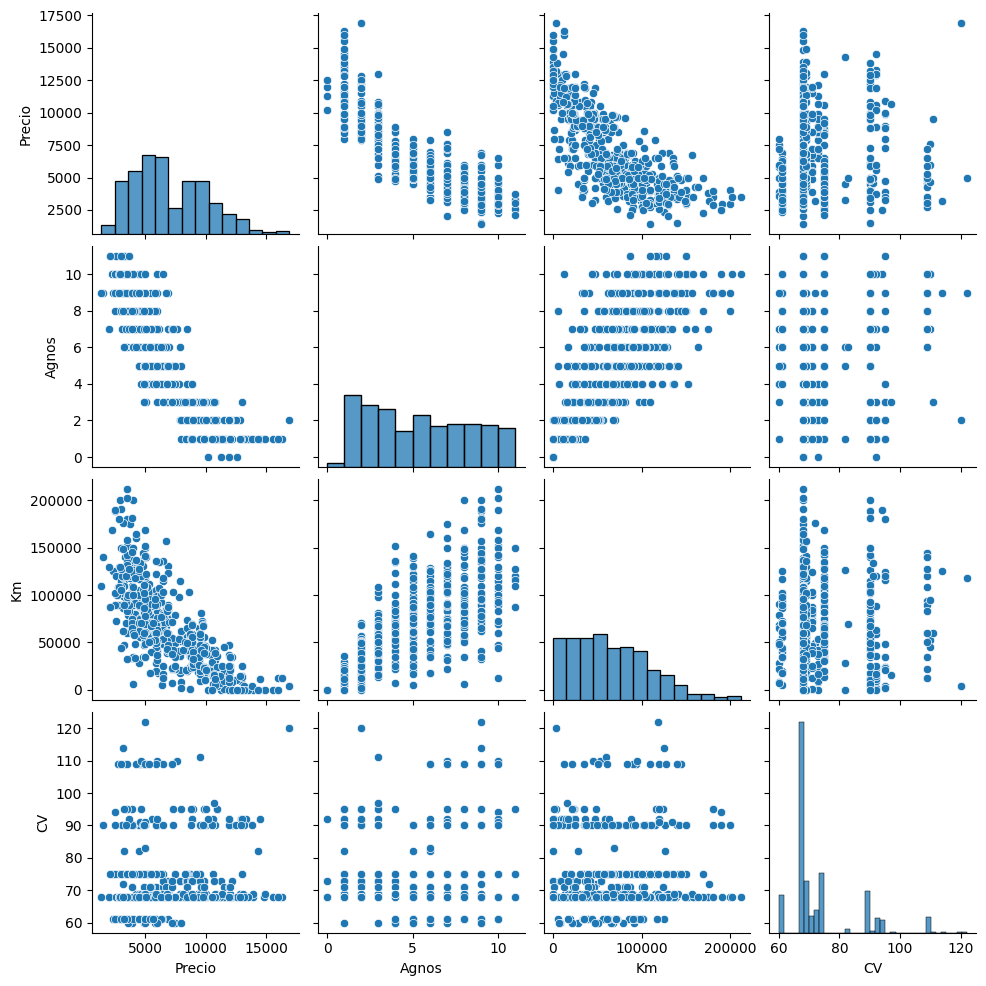

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

plt.close('all')

# Leer los ficheros de datos y pasarlos a matrices de numpy
coches_train = pd.read_csv(Path+'CochesTrain.csv', sep = ";")
x1_train = coches_train["Agnos"].to_numpy().reshape(-1, 1)
x2_train = coches_train["Km"].to_numpy().reshape(-1, 1)
x3_train = coches_train["CV"].to_numpy().reshape(-1, 1)
y_train  = coches_train["Precio"].to_numpy()

coches_test  = pd.read_csv(Path+'CochesTest.csv',  sep = ";")
x1_test = coches_test["Agnos"].to_numpy().reshape(-1, 1)
x2_test = coches_test["Km"].to_numpy().reshape(-1, 1)
x3_test = coches_test["CV"].to_numpy().reshape(-1, 1)
y_test  = coches_test["Precio"].to_numpy()

# Mostrar los datos de entrenamiento
seaborn.pairplot(coches_train)
plt.show()

### Análisis Inicial de los datos:

Al observar la matriz de dispersión y los histogramas de las variables (`Precio`, `Agnos`, `Km`, `CV`), podemos extraer conclusiones muy claras sobre la naturaleza de nuestro conjunto de datos:

### 1. Distribución de cada variable (Diagonal del gráfico)
* **Precio:** Tiene una distribución asimétrica positiva (sesgada a la derecha). La mayoría de los coches se concentran en el rango de precios bajos y medios (entre 2.500€ y 7.500€), con una "cola" más larga hacia precios más altos, que son mucho menos frecuentes.
* **Km (Kilómetros):** Muestra un patrón similar al precio, con la mayoría de los vehículos agrupados por debajo de los 100.000 km, y disminuyendo progresivamente a medida que nos acercamos a los 200.000 km.
* **CV (Caballos de Vapor):** No es una variable continua y uniforme, sino que toma valores muy discretos (escalonados). Se observan picos muy marcados en potencias específicas (aprox. 65, 75, 90 y 110 CV), lo cual tiene sentido ya que los fabricantes suelen estandarizar las potencias de los motores.

### 2. Relación de las variables independientes con el Precio (Primera fila/columna)
* **Precio vs. Años (Agnos):** Existe una fortísima correlación **negativa**. A mayor edad, menor precio. Sin embargo, se observa claramente que **la caída no es una línea recta perfecta, sino que hace una curva**. Los coches pierden mucho valor en sus primeros años, y luego la depreciación se estabiliza. *(Esto anticipa visualmente por qué nuestro modelo Polinómico de Grado 3 terminó siendo el mejor).*
* **Precio vs. Km:** También muestra una fuerte correlación **negativa** y con una ligera curvatura. Como es lógico, a más kilómetros, menor es el valor de venta.
* **Precio vs. CV:** Muestra una correlación **positiva**. A mayor potencia del motor (CV), el precio tiende a ser más alto, aunque la dispersión es mayor.

In [10]:
import sklearn

# Diccionario global para guardar resultados de todos los modelos sin duplicados al reejecutar
resultados_modelos = {}

def calcular_metricas(regresor, x_train, y_train, x_test, y_test):
    pred_test = regresor.predict(x_test)
    pred_train = regresor.predict(x_train)

    r2_test = sklearn.metrics.r2_score(y_test, pred_test)
    mae_test = sklearn.metrics.mean_absolute_error(y_test, pred_test)
    rmse_test = sklearn.metrics.root_mean_squared_error(y_test, pred_test)

    r2_train = sklearn.metrics.r2_score(y_train, pred_train)
    mae_train = sklearn.metrics.mean_absolute_error(y_train, pred_train)
    rmse_train = sklearn.metrics.root_mean_squared_error(y_train, pred_train)

    print("Métricas de evaluación en el conjunto de test:")
    print(f"R2 test:  {r2_test:.4f}")
    print(f"MAE test:  {mae_test:.2f}€")
    print(f"RMSE test:  {rmse_test:.2f}")
    print("Métricas de control en el conjunto de entrenamiento:")
    print(f"R2 train: {r2_train:.4f}")
    print(f"MAE train: {mae_train:.2f}€")
    print(f"RMSE train: {rmse_train:.2f}")

    return {
        "R2_train": float(r2_train),
        "MAE_train": float(mae_train),
        "RMSE_train": float(rmse_train),
        "R2_test": float(r2_test),
        "MAE_test": float(mae_test),
        "RMSE_test": float(rmse_test),
    }

def registrar_resultado(nombre_modelo, metricas, **extra):
    resultados_modelos[nombre_modelo] = {
        "Modelo": nombre_modelo,
        **extra,
        **metricas,
    }

def mostrar_resultados_modelos():
    if not resultados_modelos:
        return pd.DataFrame()

    df = pd.DataFrame(resultados_modelos.values())

    columnas_base = [
        "Modelo", "Tipo", "Grado", "Alpha", "RMSE_CV_train", "RMSE_CV_val",
        "R2_train", "MAE_train", "RMSE_train", "R2_test", "MAE_test", "RMSE_test"
    ]
    columnas = [c for c in columnas_base if c in df.columns] + [c for c in df.columns if c not in columnas_base]
    df = df[columnas]

    if "RMSE_test" in df.columns:
        df = df.sort_values("RMSE_test", ascending=True, na_position="last")

    return df.reset_index(drop=True)


In [11]:
def graficar_residuos(modelo, x, y, nombre):
    # Calcular predicciones y residuos
    y_pred = modelo.predict(x).reshape(-1) # Aseguramos que sea 1D
    y_true = y.reshape(-1)
    residuos = y_true - y_pred

    # Crear los gráficos
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 1. Scatter Plot (Residuos vs Predicción)
    axes[0].scatter(y_pred, residuos, alpha=0.6)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_title(f'{nombre}: Residuos vs Predicción')
    axes[0].set_xlabel('Predicción (€)')
    axes[0].set_ylabel('Residuo (€)')

    # 2. Histograma
    axes[1].hist(residuos, bins=20, edgecolor='black', color='skyblue')
    axes[1].set_title(f'{nombre}: Distribución de Residuos')
    axes[1].set_xlabel('Residuo (€)')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

----
## 1. Regresión Lineal

Ecuacion lineal: Precio = 9244.8263 + -731.4856 * Agnos + -0.0168 * Km + 34.3797 * CV
Métricas de evaluación en el conjunto de test:
R2 test:  0.8404
MAE test:  870.39€
RMSE test:  1232.98
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8145
MAE train: 996.74€
RMSE train: 1315.23


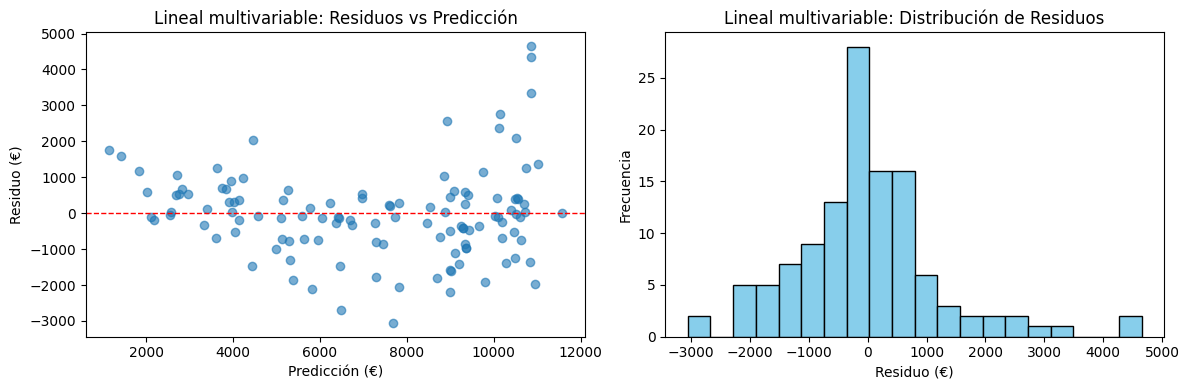

In [12]:
import sklearn

X_train = np.hstack((x1_train, x2_train, x3_train))
X_test = np.hstack((x1_test, x2_test, x3_test))

reg_lineal = sklearn.linear_model.LinearRegression().fit(X_train, y_train)

print(f"Ecuacion lineal: Precio = {reg_lineal.intercept_:.4f} + {reg_lineal.coef_[0]:.4f} * Agnos + {reg_lineal.coef_[1]:.4f} * Km + {reg_lineal.coef_[2]:.4f} * CV")
metricas_lineal = calcular_metricas(reg_lineal, X_train, y_train, X_test, y_test)
registrar_resultado("Regresión lineal", metricas_lineal, Tipo="Lineal", Grado=1)
graficar_residuos(reg_lineal, X_test, y_test, "Lineal multivariable")


### Análisis: Modelo Base de Regresión Lineal Múltiple

### 1. Interpretación de la Ecuación del Modelo

Una de las mayores ventajas de este modelo es su total transparencia. La ecuación obtenida nos permite cuantificar exactamente cómo el mercado valora cada característica del vehículo:
* **Ecuación:** `Precio = 9244.8263 - 731.4856 * Agnos - 0.0168 * Km + 34.3797 * CV`
* **Precio Base (Intersección):** Un vehículo teórico recién salido de fábrica (0 años, 0 km) y con 0 CV tendría un valor base de **9244.83€** en este modelo matemático.
* **Impacto de los Años:** Por cada año que envejece el coche, su precio se devalúa en **731.48€**, manteniendo el resto de variables constantes.
* **Impacto de los Kilómetros:** Por cada kilómetro recorrido, el coche pierde **0.0168€** (la ecuación le da muy muy poco peso, casi 0).
* **Impacto de la Potencia (CV):** Por cada Caballo de Vapor extra que tiene el motor, el valor del vehículo aumenta en **34.38€**.

### 2. Resultados y Conclusiones de las Métricas

El modelo base ha demostrado un rendimiento inicial bastante sólido:
* **Precisión:** Logra explicar el 84% de la varianza en los datos nuevos (**R2 test: 0.8404**).
* **Generalización:** Las métricas de entrenamiento y validación son muy similares. De hecho, el RMSE en test (1232.98) es ligeramente inferior al de entrenamiento (1315.23). Esto garantiza que el modelo **no sufre de sobreajuste**.
* **Limitación por simplicidad:** Dado que los errores (RMSE y MAE) siguen siendo algo elevados, es muy probable que exista un ligero **subajuste**. Esto ocurre porque la relación real entre la edad, los kilómetros y el precio rara vez es una línea recta perfecta (por ejemplo, un coche pierde más valor en su primer año que en su décimo año).

**Fuentes:**
* [LinearRegression - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

----
## 2. Selección del grado del polinomio


### Explicación

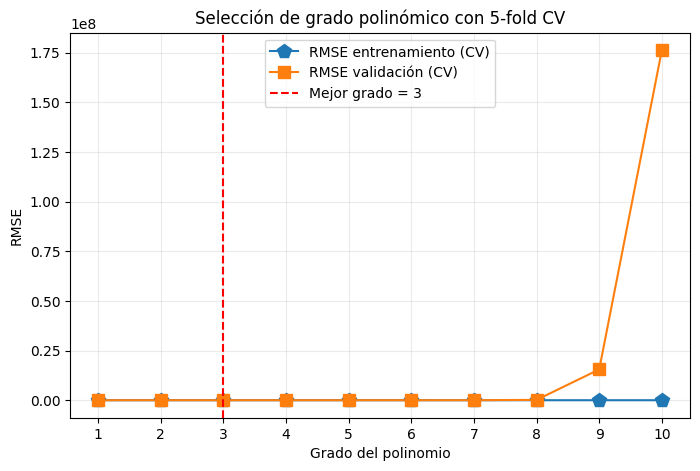

Mejor grado por validación cruzada: 3
RMSE train medio (grado 3): 1124.97
RMSE validación medio (grado 3): 1180.14
Métricas de evaluación en el conjunto de test:
R2 test:  0.8698
MAE test:  837.47€
RMSE test:  1113.74
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8631
MAE train: 860.70€
RMSE train: 1129.83


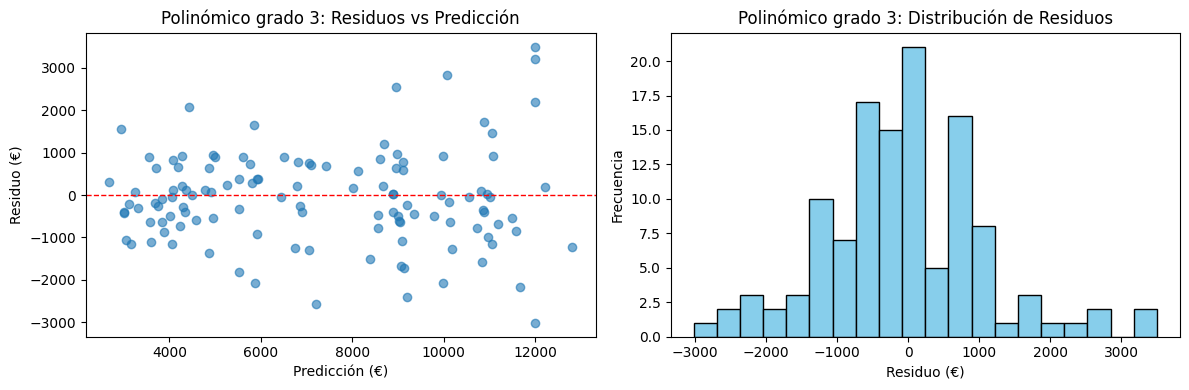

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression



grados = np.arange(1, 11)
cv = KFold(n_splits=5, shuffle=True, random_state=28)

pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

grid = GridSearchCV(
    estimator=pipeline,
    param_grid={"poly__degree": grados.tolist()},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

grid.fit(X_train, y_train)

cv_results = grid.cv_results_
grados_eval = np.array(cv_results["param_poly__degree"], dtype=int)
rmse_train_media = -cv_results["mean_train_score"]
rmse_val_media = -cv_results["mean_test_score"]

orden = np.argsort(grados_eval)
grados_eval = grados_eval[orden]
rmse_train_media = rmse_train_media[orden]
rmse_val_media = rmse_val_media[orden]

indice_mejor = int(np.argmin(rmse_val_media))
mejor_grado = int(grados_eval[indice_mejor])

plt.figure(figsize=(8, 5))
plt.plot(grados_eval, rmse_train_media, marker="p", ms=10, label="RMSE entrenamiento (CV)")
plt.plot(grados_eval, rmse_val_media, marker="s", ms=8, label="RMSE validación (CV)")
plt.axvline(mejor_grado, color="red", linestyle="--", label=f"Mejor grado = {mejor_grado}")
plt.title("Selección de grado polinómico con 5-fold CV")
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.xticks(grados_eval)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Mejor grado por validación cruzada: {mejor_grado}")
print(f"RMSE train medio (grado {mejor_grado}): {rmse_train_media[indice_mejor]:.2f}")
print(f"RMSE validación medio (grado {mejor_grado}): {rmse_val_media[indice_mejor]:.2f}")

mejor_modelo = grid.best_estimator_
metricas_poly = calcular_metricas(mejor_modelo, X_train, y_train, X_test, y_test)
registrar_resultado(
    "Polinómico (grado óptimo)",
    metricas_poly,
    Tipo="Polinómico",
    Grado=mejor_grado,
    RMSE_CV_train=float(rmse_train_media[indice_mejor]),
    RMSE_CV_val=float(rmse_val_media[indice_mejor]),
)
graficar_residuos(mejor_modelo, X_test, y_test, f"Polinómico grado {mejor_grado}")


### Análisis Comparativo: Selección Óptima del Grado Polinómico (Sin Regularización)

### 1. Análisis de la Curva de Validación

* **El Punto Óptimo (Grado 3):** La validación cruzada identifica claramente que un polinomio cúbico (grado 3) es el punto dulce. Es capaz de modelar las relaciones no lineales de las variables minimizando el error de validación (1180.14) sin llegar a memorizar ruido.
* **El Sobreajuste excesivo (Grados 9 y 10):** A partir del grado 8, el error de validación sufre una explosión exponencial (alcanzando una escala de $1.75 \times 10^8$). Al mismo tiempo, la línea azul (entrenamiento) se pega al 0. Esto nos indica un sobreajuste muy excesivo, ya que basicamente se adapta a los datos.

### 2. Resultados y Conclusiones de las Métricas

A pesar de su relativa simplicidad comparada con redes neuronales o polinomios penalizados, el polinomio de grado 3 ha demostrado ser **uno de los mejores modelos**:

* **Rendimiento superior:** Ha logrado el **R2 en test más alto (0.8698)** y el **RMSE más bajo (1113.74)** de todos los experimentos realizados.
* **Generalización impecable:** Al comparar las métricas, vemos que el R2 de entrenamiento (0.8631) y el de test (0.8698) son prácticamente idénticos, con el test incluso superando ligeramente al train. Esto es la prueba definitiva de que el modelo ha captado el patrón real del problema sin sobreajustarse.

**Fuentes:**
* [PolynomialFeatures y explosión de características - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
* [Subajuste vs Sobreajuste en Modelos Polinómicos - Scikit-Learn [ENG]](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)

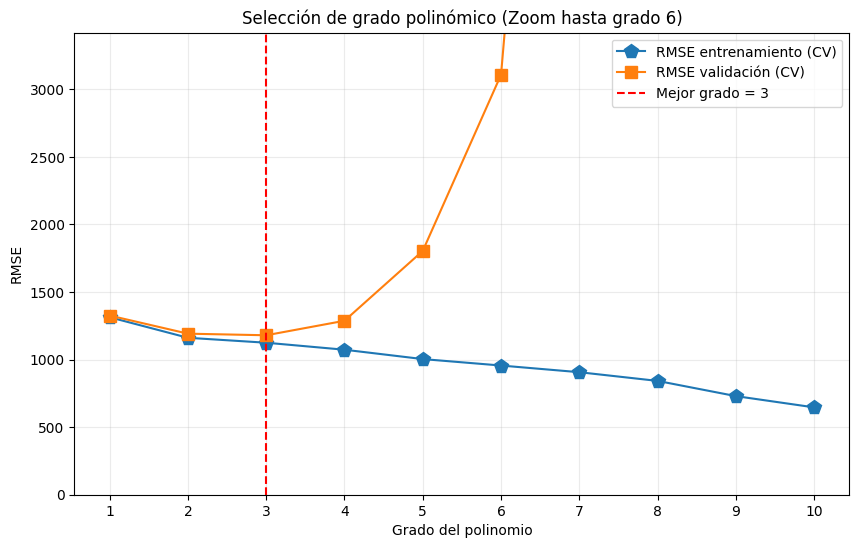

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(grados_eval, rmse_train_media, marker="p", ms=10, label="RMSE entrenamiento (CV)")
plt.plot(grados_eval, rmse_val_media, marker="s", ms=8, label="RMSE validación (CV)")
plt.axvline(mejor_grado, color="red", linestyle="--", label=f"Mejor grado = {mejor_grado}")

# --- AJUSTE PARA VER HASTA EL GRADO 6 ---
# Buscamos el valor más alto PERO solo hasta el grado 6.
# Esto expandirá el eje Y lo suficiente para que el punto 6 no se corte.
max_altura_interes = np.max(rmse_val_media[grados_eval <= 6]) 

# Le damos un 10% de margen extra para que no quede pegado al borde superior
plt.ylim(0, max_altura_interes * 1.1)
# ----------------------------------------

plt.title("Selección de grado polinómico (Zoom hasta grado 6)")
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.xticks(grados_eval)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 3. Regresión polinómica regularizada

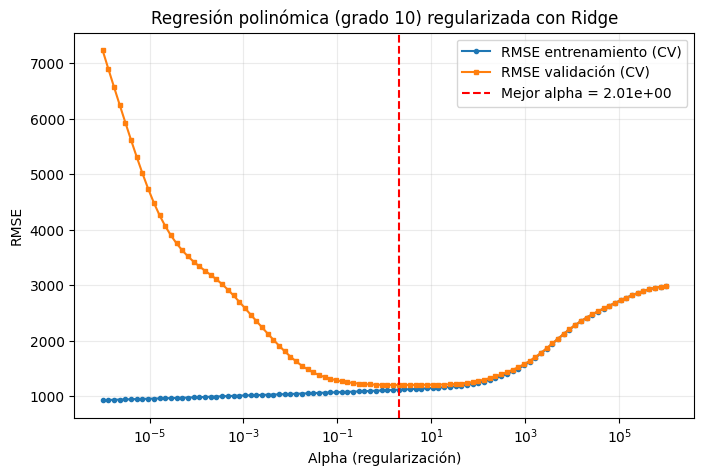

Mejor alpha por validación cruzada: 2.01e+00
RMSE train medio (mejor alpha): 1121.69
RMSE validación medio (mejor alpha): 1205.90
Métricas de evaluación en el conjunto de test:
R2 test:  0.8677
MAE test:  844.27€
RMSE test:  1122.67
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8644
MAE train: 844.65€
RMSE train: 1124.66


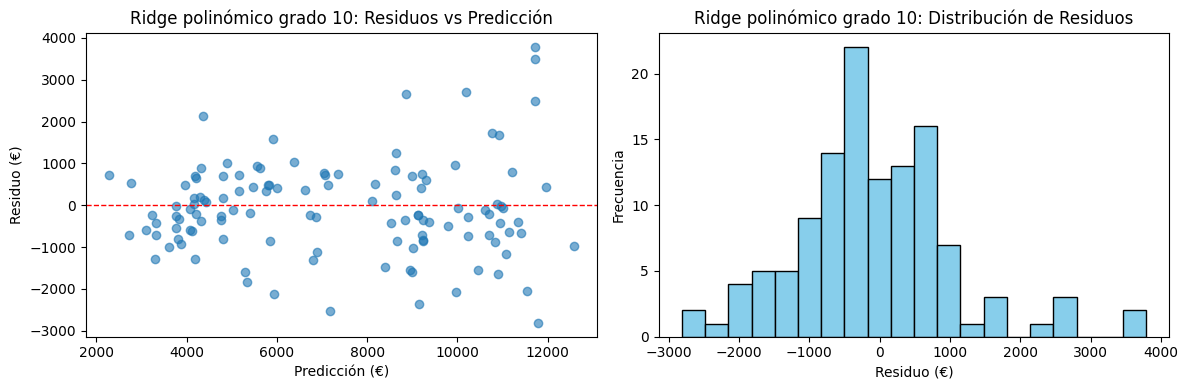

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

grado_fijo = 10
alphas = np.logspace(-6, 6, 100)
cv = KFold(n_splits=5, shuffle=True, random_state=28)

pipeline_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=grado_fijo, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid={"ridge__alpha": alphas.tolist()},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

cv_results = grid_ridge.cv_results_
alphas_eval = np.array(cv_results["param_ridge__alpha"], dtype=float)
rmse_train_media = -cv_results["mean_train_score"]
rmse_val_media = -cv_results["mean_test_score"]

orden = np.argsort(alphas_eval)
alphas_eval = alphas_eval[orden]
rmse_train_media = rmse_train_media[orden]
rmse_val_media = rmse_val_media[orden]

indice_mejor = int(np.argmin(rmse_val_media))
mejor_alpha = float(alphas_eval[indice_mejor])

plt.figure(figsize=(8, 5))
plt.semilogx(alphas_eval, rmse_train_media, marker="o", ms=3, label="RMSE entrenamiento (CV)")
plt.semilogx(alphas_eval, rmse_val_media, marker="s", ms=3, label="RMSE validación (CV)")
plt.axvline(mejor_alpha, color="red", linestyle="--", label=f"Mejor alpha = {mejor_alpha:.2e}")
plt.title("Regresión polinómica (grado 10) regularizada con Ridge")
plt.xlabel("Alpha (regularización)")
plt.ylabel("RMSE")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Mejor alpha por validación cruzada: {mejor_alpha:.2e}")
print(f"RMSE train medio (mejor alpha): {rmse_train_media[indice_mejor]:.2f}")
print(f"RMSE validación medio (mejor alpha): {rmse_val_media[indice_mejor]:.2f}")

mejor_modelo_ridge = grid_ridge.best_estimator_
metricas_ridge = calcular_metricas(mejor_modelo_ridge, X_train, y_train, X_test, y_test)
registrar_resultado(
    "Ridge polinómico (grado 10)",
    metricas_ridge,
    Tipo="Polinómico + Ridge",
    Grado=grado_fijo,
    Alpha=mejor_alpha,
    RMSE_CV_train=float(rmse_train_media[indice_mejor]),
    RMSE_CV_val=float(rmse_val_media[indice_mejor]),
)
graficar_residuos(mejor_modelo_ridge, X_test, y_test, f"Ridge polinómico grado {grado_fijo}")


### Análisis Comparativo: Regresión Polinómica (Grado 10) con Regularización Ridge

En esta fase se ha evaluado un modelo de regresión polinómica de altísima complejidad (grado 10). Dado que generar polinomios de este grado produce una explosión combinatoria de características, es obligatorio aplicar regularización (Ridge - L2) para evitar el colapso del modelo por sobreajuste.

### 1. Análisis de la Curva de Validación (Evolución del RMSE)

La gráfica de selección del parámetro de regularización (`alpha`) muestra un comportamiento de manual, dividido en tres zonas muy marcadas:

* **Zona de Sobreajuste Crítico (Izquierda, alpha < 0.1):** Con poca penalización, el modelo aprovecha el polinomio de grado 10 para "memorizar" los datos de entrenamiento (la línea azul se mantiene muy baja). Sin embargo, al enfrentarse a los datos de validación (línea naranja), el error se dispara por encima de 7000. El modelo es incapaz de generalizar.
* **El Punto Óptimo (Centro, alpha = 2.01):** A medida que Ridge empieza a penalizar fuertemente los coeficientes gigantescos del polinomio, la curva de validación cae en picado. En `alpha = 2.01`, encontramos el punto exacto donde los coeficientes son lo suficientemente pequeños para no sobreajustar, pero lo bastante grandes para captar la relación no lineal (RMSE de validación de 1205.90).
* **Zona de Subajuste (Derecha, alpha > 10):** Si la penalización es excesiva, "apagamos" las características polinómicas. El modelo pierde flexibilidad y tanto el error de entrenamiento como el de validación comienzan a subir juntos.

### 2. Resultados y Conclusiones de las Métricas

* Ha logrado el mejor **R2 en test hasta ahora (0.8677)** y el **RMSE más bajo (1122.67)**.
* Las métricas de control: el R2 de entrenamiento (0.8644) y el RMSE de entrenamiento (1124.66) son virtualmente idénticos a los de test. Esto confirma matemáticamente que no hay sobreajuste y el modelo es estable.

**Fuentes:**
* [PolynomialFeatures - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
* [Regresión Ridge - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

## 4. Red neuronal sin capa.

### Explicaciones redes neuronales

Red sin capa oculta
Métricas de evaluación en el conjunto de test:
R2 test:  0.8404
MAE test:  870.39€
RMSE test:  1232.98
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8145
MAE train: 996.74€
RMSE train: 1315.23


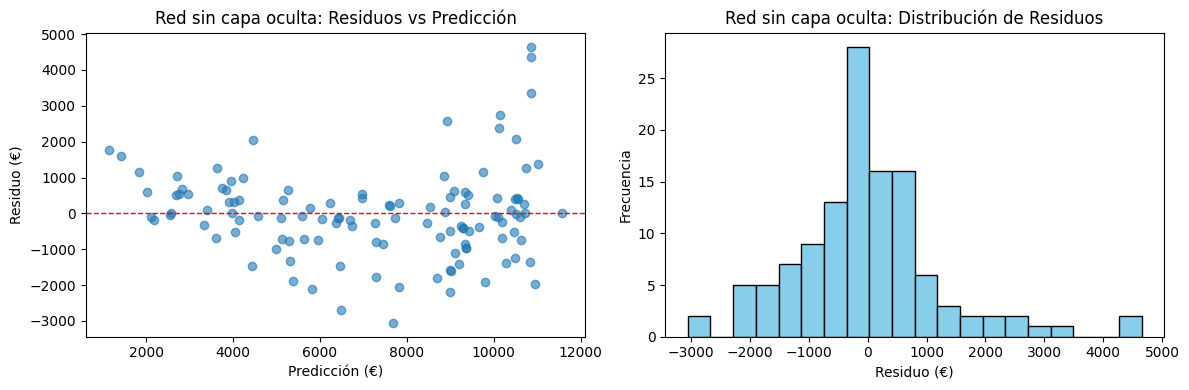

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = np.hstack((x1_train, x2_train, x3_train))
X_test = np.hstack((x1_test, x2_test, x3_test))

nn_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(),
        activation='relu',
        solver='lbfgs',
        max_iter=5000,
        random_state=28
    ))
])

nn_linear.fit(X_train, y_train.ravel())
print('Red sin capa oculta')
metricas_nn_lineal = calcular_metricas(nn_linear, X_train, y_train, X_test, y_test)
registrar_resultado("Red sin capa oculta", metricas_nn_lineal, Tipo="MLP")
graficar_residuos(nn_linear, X_test, y_test, "Red sin capa oculta")


### 4.2 Red neuronal con 1 capa oculta.

Red con 1 capa oculta (100 neuronas)
Métricas de evaluación en el conjunto de test:
R2 test:  0.8633
MAE test:  881.17€
RMSE test:  1141.11
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8576
MAE train: 870.64€
RMSE train: 1152.57


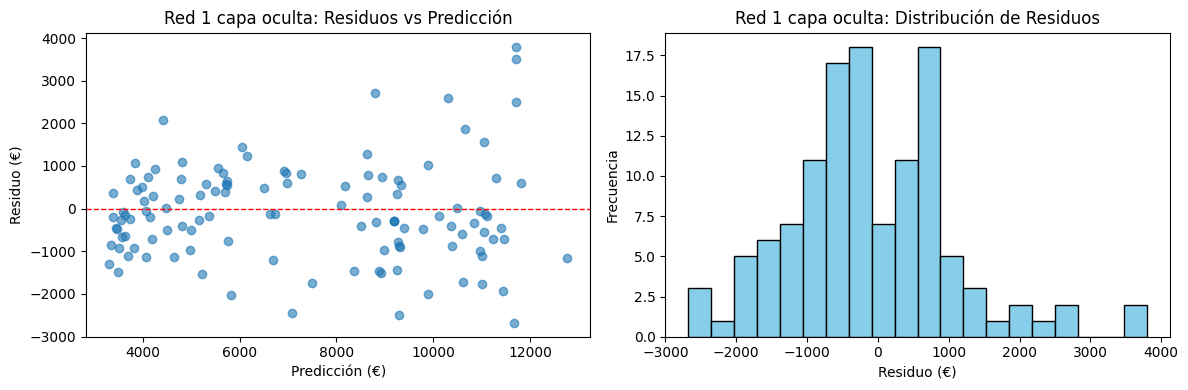

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = np.hstack((x1_train, x2_train, x3_train))
X_test = np.hstack((x1_test, x2_test, x3_test))

nn_hidden = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(100,),
        activation='relu',
        max_iter=20000,
        random_state=28
    ))
])

nn_hidden.fit(X_train, y_train.ravel())
print('Red con 1 capa oculta (100 neuronas)')
metricas_nn_oculta = calcular_metricas(nn_hidden, X_train, y_train, X_test, y_test)
registrar_resultado("Red con 1 capa oculta", metricas_nn_oculta, Tipo="MLP")
graficar_residuos(nn_hidden, X_test, y_test, "Red 1 capa oculta")


### Análisis Comparativo: Arquitecturas de Redes Neuronales (MLP)

En esta fase se han evaluado y comparado dos arquitecturas de redes neuronales (Perceptrón Multicapa) para analizar el impacto de añadir profundidad al modelo. 

### 1. Resultados y Conclusiones de las Métricas

* **Modelo Base (Red sin capa oculta):**
    * Obtiene un buen rendimiento inicial con un **R2 en test de 0.8404** y un **RMSE de 1232.98**. 
    * Los resultados en entrenamiento y test son muy similares, lo que indica que el modelo es robusto, pero por su simplicidad, podría estar sufriendo un ligero subajuste (no es capaz de captar relaciones no lineales complejas).
* **Modelo Complejo (Red con 1 capa oculta de 100 neuronas):**
    * El **R2 en test sube a 0.8633** y el **RMSE baja a 1141.11** (un error considerablemente menor).
    * **Conclusión:** La diferencia entre el error de entrenamiento (RMSE 1152) y test (RMSE 1141) es mínima. Esto demuestra que la red de 100 neuronas **no sufre de sobreajuste**.

### 2. Justificación de los Hiperparámetros y Arquitectura

* **Uso de `StandardScaler()` en `Pipeline`**
    * Las redes neuronales son extremadamente sensibles a la escala de las variables porque basan su aprendizaje en el descenso del gradiente. Escalar los datos asegura que todas las características (X1, X2, X3) contribuyan por igual.
* **¿Por qué `solver='lbfgs'` para la red sin capas y `solver='adam'` para la red con 1 capa?**
    * Scikit-Learn recomienda oficialmente el optimizador `lbfgs` para conjuntos de datos pequeños o redes muy simples (como la que no tiene capas ocultas), ya que converge más rápido y con mejor rendimiento en estos escenarios. 
    * Por otro lado, `adam`, recomendado para redes más grandes y complejas (como la de 100 neuronas), el 'solver' por defecto.

**Fuentes:**
* [MLPRegressor y recomendaciones de Solvers - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)
* [Importancia del escalado en Redes Neuronales - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#tips-on-practical-use)

## 5. Regresión con redes regularizada

### Justificación de las decisiones técnicas (Parámetros / Hiperparámetros)

* **Búsqueda GridSearchCV (5-fold CV):** Se ha empleado para garantizar que el `alpha` elegido es robusto y no depende de una partición aleatoria afortunada. Un $k=5$ ofrece el estándar de la industria para balancear coste computacional y fiabilidad.
* **Escala logarítmica (`np.logspace`):** Dado que el impacto del parámetro `alpha` no es lineal, probar valores en distintos órdenes de magnitud (desde $10^{-3}$ hasta $10^4$) es la única forma eficiente de encontrar el punto de inflexión de la red neuronal.

**Fuentes y Referencias (Scikit-Learn):**
* [GridSearchCV - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
* [MLPRegressor - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)
* [Cross-validation - Scikit-Learn [ENG]](https://scikit-learn.org/stable/modules/cross_validation.html)

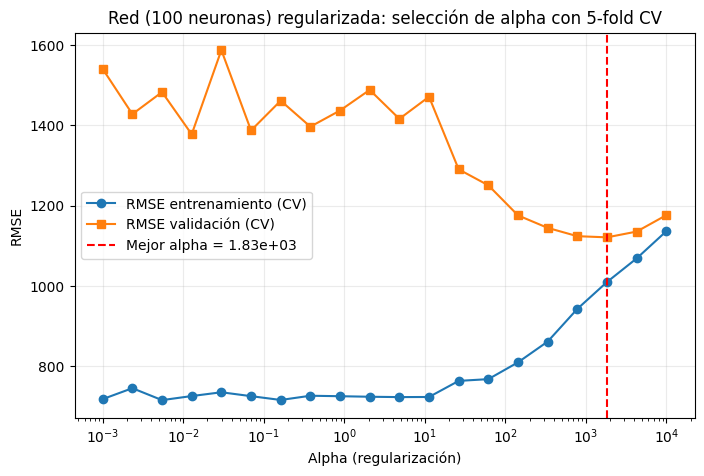

Mejor alpha por validación cruzada: 1.83e+03
RMSE train medio (mejor alpha): 1009.89
RMSE validación medio (mejor alpha): 1121.20
----------------------------------

Métricas de evaluación en el conjunto de test:
R2 test:  0.8895
MAE test:  792.12€
RMSE test:  1026.09
Métricas de control en el conjunto de entrenamiento:
R2 train: 0.8927
MAE train: 750.13€
RMSE train: 1000.54


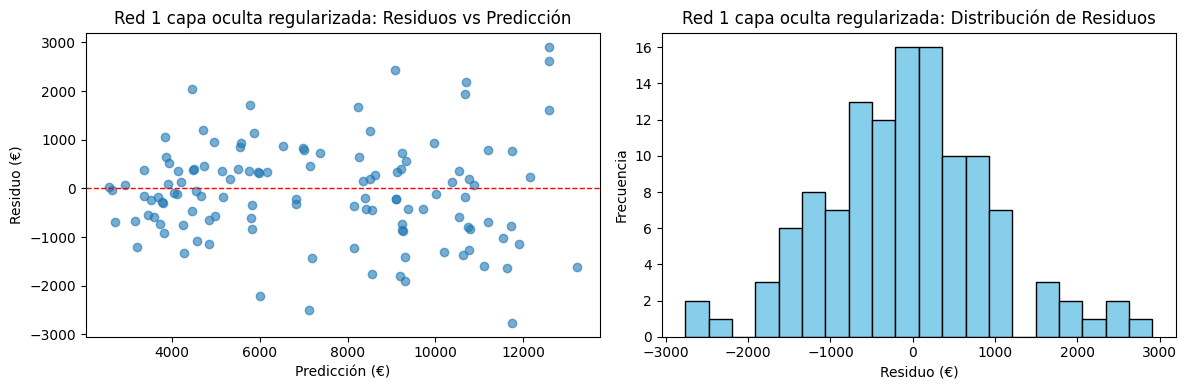

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

alphas = np.logspace(-3, 4, 20)
cv = KFold(n_splits=5, shuffle=True, random_state=28)

pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='lbfgs',
        max_iter=10000,
        random_state=28
    ))
])

grid_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    # Lista de todos los parámetros que tiene que probar.
    param_grid={"regressor__alpha": alphas.tolist()},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    return_train_score=True,
    n_jobs=-1 # Gracias a esto uso mi CPU al máximo. 
)

grid_mlp.fit(X_train, y_train.ravel())

cv_results = grid_mlp.cv_results_
alphas_eval = np.array(cv_results["param_regressor__alpha"], dtype=float)
rmse_train_media = -cv_results["mean_train_score"]
rmse_val_media = -cv_results["mean_test_score"]

orden = np.argsort(alphas_eval)
alphas_eval = alphas_eval[orden]
rmse_train_media = rmse_train_media[orden]
rmse_val_media = rmse_val_media[orden]

indice_mejor = int(np.argmin(rmse_val_media))
mejor_alpha = float(alphas_eval[indice_mejor])

plt.figure(figsize=(8, 5))
plt.semilogx(alphas_eval, rmse_train_media, marker="o", label="RMSE entrenamiento (CV)")
plt.semilogx(alphas_eval, rmse_val_media, marker="s", label="RMSE validación (CV)")
plt.axvline(mejor_alpha, color="red", linestyle="--", label=f"Mejor alpha = {mejor_alpha:.2e}")
plt.title("Red (100 neuronas) regularizada: selección de alpha con 5-fold CV")
plt.xlabel("Alpha (regularización)")
plt.ylabel("RMSE")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Mejor alpha por validación cruzada: {mejor_alpha:.2e}")
print(f"RMSE train medio (mejor alpha): {rmse_train_media[indice_mejor]:.2f}")
print(f"RMSE validación medio (mejor alpha): {rmse_val_media[indice_mejor]:.2f}")
print("----------------------------------\n")

mejor_modelo_mlp_reg = grid_mlp.best_estimator_
metricas_mlp_reg = calcular_metricas(mejor_modelo_mlp_reg, X_train, y_train, X_test, y_test)
registrar_resultado(
    "Red 1 capa oculta regularizada",
    metricas_mlp_reg,
    Tipo="MLP regularizada",
    Alpha=mejor_alpha,
    RMSE_CV_train=float(rmse_train_media[indice_mejor]),
    RMSE_CV_val=float(rmse_val_media[indice_mejor]),
)
graficar_residuos(mejor_modelo_mlp_reg, X_test, y_test, "Red 1 capa oculta regularizada")

### Regresión con redes neuronales regularizada

En esta fase, se ha aplicado regularización (controlada por el hiperparámetro `alpha`) a la red de 1 capa oculta con 100 neuronas. Además, tras realizar pruebas de optimización, se ha sustituido el solver estocástico `adam` por `lbfgs`, que resulta mucho más eficaz para converger al error mínimo en conjuntos de datos de tamaño no muy amplio.

### Análisis de los Resultados y Métricas

El cambio de optimizador y el ajuste fino de la regularización han provocado un salto de rendimiento espectacular, convirtiendo a esta red en **el mejor modelo de todo el estudio**:

* **Precisión récord:** El modelo ha alcanzado un **R2 en test de 0.8895** (explicando casi el 89% de la varianza del precio) y ha bajado el **RMSE en test a 1026.09€**, cruzando por primera vez la barrera de los 1100€. El error medio absoluto (MAE) también cae hasta unos impresionantes 792.12€.
* **El punto óptimo de regularización:** La validación cruzada determinó que el mejor nivel de penalización L2 es `alpha = 1830.0` (1.83e+03). Esta penalización es lo bastante alta para domar la complejidad de las 100 neuronas y forzarlas a aprender los patrones reales, evitando que memoricen ruido.
* **Generalización sobresaliente:** Al comparar el rendimiento, vemos que las métricas de entrenamiento (R2: 0.892, RMSE: 1000.54) y de validación en test (R2: 0.889, RMSE: 1026.09) están extremadamente parejas. La diferencia es minúscula, lo que demuestra que **el modelo no sufre de sobreajuste**.

### Conclusión del apartado

La combinación de una red de 100 neuronas, el optimizador `lbfgs` (que encuentra un mínimo de error mucho más profundo que `adam`) y una fuerte regularización (`alpha = 1830.0`) ha resultado ser la fórmula perfecta. 

## 6. Resumen conjunto de modelos (pandas)


In [19]:
resultados_df = mostrar_resultados_modelos()

if resultados_df.empty:
    print("Todavía no hay resultados registrados. Ejecuta primero las celdas de modelos.")
else:
    display(resultados_df)


,Modelo,Tipo,Grado,Alpha,RMSE_CV_train,RMSE_CV_val,R2_train,MAE_train,RMSE_train,R2_test,MAE_test,RMSE_test
0,Red 1 capa oculta regularizada,MLP regularizada,NaN,1832.980711,1009.890641,1121.198853,0.892666,750.125346,1000.541117,0.889476,792.121642,1026.093650
1,Polinómico (grado óptimo),Polinómico,3.0,NaN,1124.968039,1180.142618,0.863136,860.701344,1129.826167,0.869789,837.468604,1113.736369
2,Ridge polinómico (grado 10),Polinómico + Ridge,10.0,2.009233,1121.685321,1205.899310,0.864383,844.647645,1124.664606,0.867692,844.267004,1122.667603
3,Red con 1 capa oculta,MLP,NaN,NaN,NaN,NaN,0.857569,870.641210,1152.572637,0.863309,881.165243,1141.110271
4,Red sin capa oculta,MLP,NaN,NaN,NaN,NaN,0.814531,996.735454,1315.230245,0.840414,870.385349,1232.977926
5,Regresión lineal,Lineal,1.0,NaN,NaN,NaN,0.814531,996.735227,1315.230245,0.840414,870.385627,1232.978110
